# DATA 266 — Self-Supervised & Contrastive Representation Learning (STL-10)
**Student:** Ritika Mukesh Neema | **SID4:** 6638

Backbone for every part: **ResNet-18, no pretrained weights**. Parts: (A) supervised on 10% labels, (B) rotation SSL + frozen linear probe, (C) SimCLR (τ = 0.2) + frozen linear probe, (D) cosine nearest-neighbour visualisation.

## Step 0 — Setup
Parameters derived from SID4, global seeding, private repo `data266-6638` (shared with instructor), deliverables: this notebook, report, `METRICS.md`, `RUN_LOG.txt`, `AI_USE.md`.

In [2]:
# ===== STEP 0: parameters & seeding =====
import os, random, time, json, math
import numpy as np, torch, torch.nn as nn, torch.nn.functional as F
import matplotlib; matplotlib.use("Agg") if os.environ.get("SMOKE") else None
import matplotlib.pyplot as plt

SMOKE = bool(os.environ.get("SMOKE"))   # tiny CPU dry-run flag (leave unset in Colab)

SID4  = 6638
SEED  = SID4
SLICE = SID4 % 1000
HP_ID = SID4 % 6
CLS_A = SID4 % 10
CLS_B = (CLS_A + 1 + ((SID4 // 10) % 9)) % 10
print(f"SID4={SID4} SEED={SEED} SLICE={SLICE} HP_ID={HP_ID} CLS_A={CLS_A} CLS_B={CLS_B}")

def set_seeds(seed=SEED):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
set_seeds()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
AMP = device.type == "cuda"
print("device:", device, "| AMP:", AMP)

LOG_PATH = "RUN_LOG.txt"
open(LOG_PATH, "w").write(f"RUN_LOG.txt — STL-10 SSL, SID4={SID4}, SEED={SEED}\n")
def log(*a):
    s = " ".join(str(x) for x in a); print(s)
    with open(LOG_PATH, "a") as f: f.write(s + "\n")
RESULTS = {}

SID4=6638 SEED=6638 SLICE=638 HP_ID=2 CLS_A=8 CLS_B=5
device: cuda | AMP: True


## Data — STL-10 (96×96): 5,000 labeled train, 100,000 unlabeled, 8,000 test

In [3]:
CLASSES = ["airplane","bird","car","cat","deer","dog","horse","monkey","ship","truck"]
MEAN = torch.tensor([0.4467, 0.4398, 0.4066], device=device).view(1,3,1,1)
STD  = torch.tensor([0.2603, 0.2566, 0.2713], device=device).view(1,3,1,1)

if SMOKE:
    g = np.random.RandomState(0)
    def fake(n, lab=True):
        x = g.randint(0,256,(n,3,32,32),dtype=np.uint8); y = np.arange(n)%10 if lab else None
        return x, y
    Xtr, ytr = fake(200); Xte, yte = fake(100); Xun, _ = fake(300, False)
else:
    from torchvision.datasets import STL10
    tr = STL10("./data", split="train", download=True)
    te = STL10("./data", split="test", download=True)
    un = STL10("./data", split="unlabeled", download=True)
    Xtr, ytr, Xte, yte, Xun = tr.data, tr.labels, te.data, te.labels, un.data   # uint8 N,3,96,96

# keep everything as uint8 tensors on the GPU; augmentation is done on-GPU (Colab CPUs are slow)
Xtr = torch.from_numpy(Xtr).to(device); Xte = torch.from_numpy(Xte).to(device); Xun = torch.from_numpy(Xun).to(device)
ytr = torch.as_tensor(ytr).long().to(device); yte = torch.as_tensor(yte).long().to(device)
log(f"train {tuple(Xtr.shape)} | unlabeled {tuple(Xun.shape)} | test {tuple(Xte.shape)}")

# 10% labeled subset = 500 images, stratified (50 / class), chosen with SEED — reused in Parts A, B, C
rng = np.random.RandomState(SEED)
ytr_np = ytr.cpu().numpy(); per_class = max(1, len(ytr_np) // 10 // 10)
idx10 = np.concatenate([rng.choice(np.where(ytr_np == c)[0], per_class, replace=False) for c in range(10)])
idx10 = torch.as_tensor(idx10, device=device)
X10, y10 = Xtr[idx10], ytr[idx10]
log(f"10% labeled subset: {len(idx10)} images, class counts = {torch.bincount(y10, minlength=10).tolist()}")

100%|██████████| 2.64G/2.64G [03:37<00:00, 12.1MB/s]


train (5000, 3, 96, 96) | unlabeled (100000, 3, 96, 96) | test (8000, 3, 96, 96)
10% labeled subset: 500 images, class counts = [50, 50, 50, 50, 50, 50, 50, 50, 50, 50]


## Shared utilities
GPU-side batch augmentation with the **four SimCLR augmentations**: random resized crop, horizontal flip, colour jitter (brightness/contrast/saturation), random grayscale. Each sample gets its own random parameters.

In [4]:
import torchvision

def to_float(xu8): return xu8.float() / 255.0
def norm(x): return (x - MEAN) / STD

def gpu_aug(xu8, crop_scale=(0.2, 1.0), flip=True, jitter=True, gray=True, jitter_p=0.8, gray_p=0.2):
    x = to_float(xu8); B, _, H, W = x.shape; d = x.device
    # 1) random resized crop (+ 2) horizontal flip) via one affine grid
    area  = torch.empty(B, device=d).uniform_(*crop_scale)
    logr  = torch.empty(B, device=d).uniform_(math.log(3/4), math.log(4/3)); ratio = torch.exp(logr)
    w = torch.sqrt(area * ratio).clamp(max=1.0); h = torch.sqrt(area / ratio).clamp(max=1.0)
    cx = (torch.rand(B, device=d) * 2 - 1) * (1 - w); cy = (torch.rand(B, device=d) * 2 - 1) * (1 - h)
    sgn = torch.where(torch.rand(B, device=d) < 0.5, -1.0, 1.0) if flip else torch.ones(B, device=d)
    theta = torch.zeros(B, 2, 3, device=d)
    theta[:, 0, 0] = w * sgn; theta[:, 0, 2] = cx; theta[:, 1, 1] = h; theta[:, 1, 2] = cy
    grid = F.affine_grid(theta, x.shape, align_corners=False)
    x = F.grid_sample(x, grid, mode="bilinear", padding_mode="reflection", align_corners=False)
    # 3) colour jitter (applied with prob jitter_p)
    if jitter:
        m = (torch.rand(B, 1, 1, 1, device=d) < jitter_p).float()
        b = torch.empty(B,1,1,1,device=d).uniform_(0.6,1.4); c = torch.empty(B,1,1,1,device=d).uniform_(0.6,1.4)
        s = torch.empty(B,1,1,1,device=d).uniform_(0.6,1.4)
        xj = (x * b).clamp(0,1)
        mu = xj.mean(dim=(1,2,3), keepdim=True); xj = ((xj - mu) * c + mu).clamp(0,1)
        gr = (0.299*xj[:,0:1] + 0.587*xj[:,1:2] + 0.114*xj[:,2:3]); xj = ((xj - gr) * s + gr).clamp(0,1)
        x = m * xj + (1 - m) * x
    # 4) random grayscale
    if gray:
        m = (torch.rand(B, 1, 1, 1, device=d) < gray_p).float()
        gr = (0.299*x[:,0:1] + 0.587*x[:,1:2] + 0.114*x[:,2:3]).expand(-1,3,-1,-1)
        x = m * gr + (1 - m) * x
    return norm(x)

def make_encoder():
    m = torchvision.models.resnet18(weights=None)      # NO pretrained weights
    m.fc = nn.Identity()                                # 512-d embedding
    return m.to(device).to(memory_format=torch.channels_last)

@torch.no_grad()
def extract(encoder, xu8, bs=500):
    encoder.eval(); out = []
    for i in range(0, len(xu8), bs):
        with torch.autocast(device.type, enabled=AMP):
            out.append(encoder(norm(to_float(xu8[i:i+bs])).contiguous(memory_format=torch.channels_last)).float())
    return torch.cat(out)

@torch.no_grad()
def accuracy_from_logits(model, xu8, y, bs=500):
    model.eval(); correct = 0
    for i in range(0, len(xu8), bs):
        with torch.autocast(device.type, enabled=AMP):
            correct += (model(norm(to_float(xu8[i:i+bs])).contiguous(memory_format=torch.channels_last)).argmax(1) == y[i:i+bs]).sum().item()
    return correct / len(xu8)

def param_checksum(m): return sum(p.double().sum().item() for p in m.state_dict().values() if p.dtype.is_floating_point)

def linear_probe(encoder, epochs=20, lr=5e-3, bs=64, tag=""):
    # Frozen-encoder linear evaluation on the SAME 500-image labeled subset.
    for p in encoder.parameters(): p.requires_grad_(False)
    encoder.eval()
    before = param_checksum(encoder)
    ftr, fte = extract(encoder, X10), extract(encoder, Xte)           # encoder never receives gradients
    mu, sd = ftr.mean(0, keepdim=True), ftr.std(0, keepdim=True) + 1e-6
    ftr, fte = (ftr - mu) / sd, (fte - mu) / sd
    clf = nn.Linear(512, 10).to(device); opt = torch.optim.Adam(clf.parameters(), lr=lr, weight_decay=1e-4)
    hist = []
    for ep in range(epochs):
        perm = torch.randperm(len(ftr), device=device); tot = 0
        for i in range(0, len(ftr), bs):
            j = perm[i:i+bs]; loss = F.cross_entropy(clf(ftr[j]), y10[j])
            opt.zero_grad(); loss.backward(); opt.step(); tot += loss.item() * len(j)
        hist.append(tot / len(ftr))
    with torch.no_grad(): acc = (clf(fte).argmax(1) == yte).float().mean().item()
    assert param_checksum(encoder) == before, "encoder changed during linear eval!"
    log(f"[{tag}] linear probe: epochs={epochs} final train loss={hist[-1]:.4f} | TEST ACC = {acc*100:.2f}% (encoder verified frozen)")
    return acc, hist

def plot_curve(y, title, ylabel="loss"):
    plt.figure(figsize=(4.5,3)); plt.plot(range(1,len(y)+1), y, marker="o"); plt.title(title)
    plt.xlabel("epoch"); plt.ylabel(ylabel); plt.grid(alpha=.3); plt.tight_layout()
    plt.savefig(title.replace(" ","_").replace("/","-") + ".png", dpi=130); plt.show()

EP_FAST = 2 if SMOKE else None   # smoke test overrides epochs
def E(n): return EP_FAST or n

## Part A — Supervised baseline (10% labels = 500 images, ResNet-18 end-to-end)

[A] epoch 1/15 loss=2.3343
[A] epoch 2/15 loss=1.8264
[A] epoch 3/15 loss=1.6396
[A] epoch 4/15 loss=1.4970
[A] epoch 5/15 loss=1.4409
[A] epoch 6/15 loss=1.3594
[A] epoch 7/15 loss=1.2884
[A] epoch 8/15 loss=1.1966
[A] epoch 9/15 loss=1.1184
[A] epoch 10/15 loss=1.1099
[A] epoch 11/15 loss=1.1646
[A] epoch 12/15 loss=1.1518
[A] epoch 13/15 loss=1.0054
[A] epoch 14/15 loss=0.9961
[A] epoch 15/15 loss=0.8831
[A] Supervised (10% labels) TEST ACC = 38.12%  (7s)


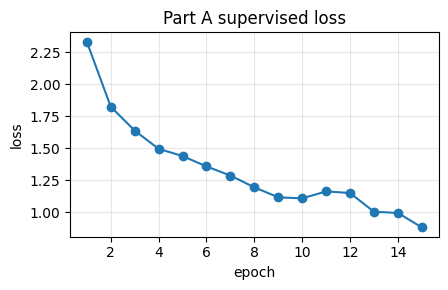

In [5]:
set_seeds()
EPOCHS_A, BS_A, LR_A = E(15), 64, 1e-3
model_A = nn.Sequential(make_encoder(), nn.Linear(512, 10)).to(device)
opt = torch.optim.Adam(model_A.parameters(), lr=LR_A, weight_decay=1e-4)
scaler = torch.amp.GradScaler(enabled=AMP); histA = []
t0 = time.time()
for ep in range(EPOCHS_A):
    model_A.train(); perm = torch.randperm(len(X10), device=device); tot = 0
    for i in range(0, len(X10), BS_A):
        j = perm[i:i+BS_A]
        xb = gpu_aug(X10[j], crop_scale=(0.5, 1.0), flip=True, jitter=False, gray=False).contiguous(memory_format=torch.channels_last)
        with torch.autocast(device.type, enabled=AMP): loss = F.cross_entropy(model_A(xb), y10[j])
        opt.zero_grad(); scaler.scale(loss).backward(); scaler.step(opt); scaler.update(); tot += loss.item() * len(j)
    histA.append(tot / len(X10)); log(f"[A] epoch {ep+1}/{EPOCHS_A} loss={histA[-1]:.4f}")
accA = accuracy_from_logits(model_A, Xte, yte)
log(f"[A] Supervised (10% labels) TEST ACC = {accA*100:.2f}%  ({time.time()-t0:.0f}s)")
RESULTS["A"] = dict(acc=accA, epochs=EPOCHS_A, bs=BS_A, lr=LR_A, loss=histA)
plot_curve(histA, "Part A supervised loss")
enc_A = model_A[0]

## Part B — Rotation self-supervised learning (all 100k unlabeled images) → frozen linear probe

[B] epoch 1/15 rot-loss=1.0169 rot-acc=57.1% (24s)
[B] epoch 2/15 rot-loss=0.8299 rot-acc=66.2% (47s)
[B] epoch 3/15 rot-loss=0.7455 rot-acc=70.1% (71s)
[B] epoch 4/15 rot-loss=0.6846 rot-acc=72.9% (96s)
[B] epoch 5/15 rot-loss=0.6421 rot-acc=74.7% (120s)
[B] epoch 6/15 rot-loss=0.6066 rot-acc=76.1% (144s)
[B] epoch 7/15 rot-loss=0.5728 rot-acc=77.7% (169s)
[B] epoch 8/15 rot-loss=0.5507 rot-acc=78.7% (194s)
[B] epoch 9/15 rot-loss=0.5281 rot-acc=79.4% (218s)
[B] epoch 10/15 rot-loss=0.5077 rot-acc=80.5% (242s)
[B] epoch 11/15 rot-loss=0.4909 rot-acc=81.0% (266s)
[B] epoch 12/15 rot-loss=0.4756 rot-acc=81.7% (290s)
[B] epoch 13/15 rot-loss=0.4577 rot-acc=82.4% (315s)
[B] epoch 14/15 rot-loss=0.4483 rot-acc=82.7% (339s)
[B] epoch 15/15 rot-loss=0.4367 rot-acc=83.2% (363s)


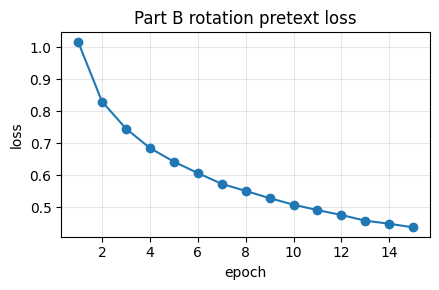

[B rotation] linear probe: epochs=20 final train loss=0.7535 | TEST ACC = 49.31% (encoder verified frozen)


In [6]:
set_seeds()
EPOCHS_B, BS_B, LR_B = E(15), 256, 1e-3
enc_B = make_encoder(); rot_head = nn.Linear(512, 4).to(device)
opt = torch.optim.Adam(list(enc_B.parameters()) + list(rot_head.parameters()), lr=LR_B)
scaler = torch.amp.GradScaler(enabled=AMP); histB = []; histBacc = []
t0 = time.time(); N = len(Xun)
for ep in range(EPOCHS_B):
    enc_B.train(); perm = torch.randperm(N, device=device); tot = cor = seen = 0
    for i in range(0, N - BS_B + 1, BS_B):
        xb = gpu_aug(Xun[perm[i:i+BS_B]], crop_scale=(0.6, 1.0), flip=True, jitter=False, gray=False)
        k = torch.randint(0, 4, (len(xb),), device=device)          # 0/90/180/270 deg, one random rotation per image per step
        xr = torch.empty_like(xb)
        for r in range(4):
            m = k == r
            if m.any(): xr[m] = torch.rot90(xb[m], r, dims=(2, 3))
        xr = xr.contiguous(memory_format=torch.channels_last)
        with torch.autocast(device.type, enabled=AMP):
            logits = rot_head(enc_B(xr)); loss = F.cross_entropy(logits, k)
        opt.zero_grad(); scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
        tot += loss.item() * len(k); cor += (logits.argmax(1) == k).sum().item(); seen += len(k)
    histB.append(tot / seen); histBacc.append(cor / seen)
    log(f"[B] epoch {ep+1}/{EPOCHS_B} rot-loss={histB[-1]:.4f} rot-acc={histBacc[-1]*100:.1f}% ({time.time()-t0:.0f}s)")
plot_curve(histB, "Part B rotation pretext loss")
del rot_head                                           # remove the rotation head
accB, histB_lin = linear_probe(enc_B, epochs=E(20), tag="B rotation")
RESULTS["B"] = dict(acc=accB, pretrain_epochs=EPOCHS_B, pretext_acc=histBacc[-1], linear_epochs=E(20), loss=histB)

## Part C — SimCLR-style contrastive learning (20,000 unlabeled images, τ = 0.2) → frozen linear probe

[C] epoch 1/20 NT-Xent=5.3746 contrastive-top1=3.8% (10s)
[C] epoch 2/20 NT-Xent=4.5784 contrastive-top1=12.6% (20s)
[C] epoch 3/20 NT-Xent=4.1745 contrastive-top1=21.3% (30s)
[C] epoch 4/20 NT-Xent=3.7976 contrastive-top1=33.8% (41s)
[C] epoch 5/20 NT-Xent=3.5627 contrastive-top1=42.1% (51s)
[C] epoch 6/20 NT-Xent=3.4228 contrastive-top1=48.7% (61s)
[C] epoch 7/20 NT-Xent=3.2951 contrastive-top1=54.3% (71s)
[C] epoch 8/20 NT-Xent=3.2056 contrastive-top1=58.4% (81s)
[C] epoch 9/20 NT-Xent=3.1141 contrastive-top1=63.1% (91s)
[C] epoch 10/20 NT-Xent=3.0612 contrastive-top1=64.9% (101s)
[C] epoch 11/20 NT-Xent=2.9988 contrastive-top1=68.3% (111s)
[C] epoch 12/20 NT-Xent=2.9419 contrastive-top1=70.7% (121s)
[C] epoch 13/20 NT-Xent=2.9016 contrastive-top1=72.1% (131s)
[C] epoch 14/20 NT-Xent=2.8748 contrastive-top1=73.5% (141s)
[C] epoch 15/20 NT-Xent=2.8441 contrastive-top1=74.8% (152s)
[C] epoch 16/20 NT-Xent=2.8040 contrastive-top1=76.7% (162s)
[C] epoch 17/20 NT-Xent=2.7825 contrastive-

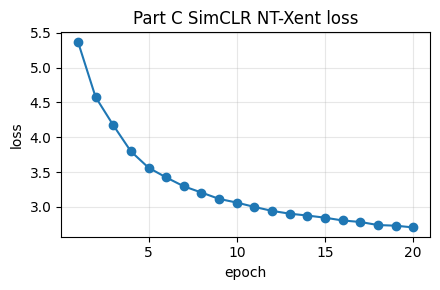

[C SimCLR] linear probe: epochs=20 final train loss=0.4555 | TEST ACC = 53.80% (encoder verified frozen)


In [7]:
set_seeds()
EPOCHS_C, BS_C, LR_C, TAU, NSUB = E(20), 256, 1e-3, 0.2, (len(Xun) if SMOKE else 20000)
sub = torch.as_tensor(np.random.RandomState(SEED).choice(len(Xun), NSUB, replace=False), device=device)
Xc = Xun[sub]
enc_C = make_encoder()
proj = nn.Sequential(nn.Linear(512, 512), nn.ReLU(inplace=True), nn.Linear(512, 128)).to(device)   # projection head (MLP)
opt = torch.optim.Adam(list(enc_C.parameters()) + list(proj.parameters()), lr=LR_C, weight_decay=1e-6)
scaler = torch.amp.GradScaler(enabled=AMP)

def nt_xent(z1, z2, tau):
    B = z1.shape[0]; z = F.normalize(torch.cat([z1, z2]).float(), dim=1)      # cosine similarity via L2-normalised dot product
    sim = z @ z.T / tau
    sim.fill_diagonal_(float("-inf"))
    tgt = torch.cat([torch.arange(B, 2*B), torch.arange(0, B)]).to(z.device)   # positive of i is i+B (and vice versa)
    return F.cross_entropy(sim, tgt), (sim.argmax(1) == tgt).float().mean().item()

histC = []; t0 = time.time()
for ep in range(EPOCHS_C):
    enc_C.train(); proj.train(); perm = torch.randperm(NSUB, device=device); tot = acc_ = nb = 0
    for i in range(0, NSUB - BS_C + 1, BS_C):
        xb = Xc[perm[i:i+BS_C]]
        v1 = gpu_aug(xb).contiguous(memory_format=torch.channels_last)           # two independently augmented views
        v2 = gpu_aug(xb).contiguous(memory_format=torch.channels_last)
        with torch.autocast(device.type, enabled=AMP):
            z = proj(enc_C(torch.cat([v1, v2])))
        loss, a = nt_xent(z[:len(xb)], z[len(xb):], TAU)
        opt.zero_grad(); scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
        tot += loss.item(); acc_ += a; nb += 1
    histC.append(tot / nb); log(f"[C] epoch {ep+1}/{EPOCHS_C} NT-Xent={histC[-1]:.4f} contrastive-top1={acc_/nb*100:.1f}% ({time.time()-t0:.0f}s)")
plot_curve(histC, "Part C SimCLR NT-Xent loss")
del proj                                               # remove the projection head
accC, histC_lin = linear_probe(enc_C, epochs=E(20), tag="C SimCLR")
RESULTS["C"] = dict(acc=accC, pretrain_epochs=EPOCHS_C, tau=TAU, n_unlabeled=NSUB, linear_epochs=E(20), loss=histC)

## Part D — Nearest-neighbour retrieval on test-set embeddings (cosine similarity)

query test indices: [3808, 2548, 3442] | classes: ['cat', 'deer', 'bird']


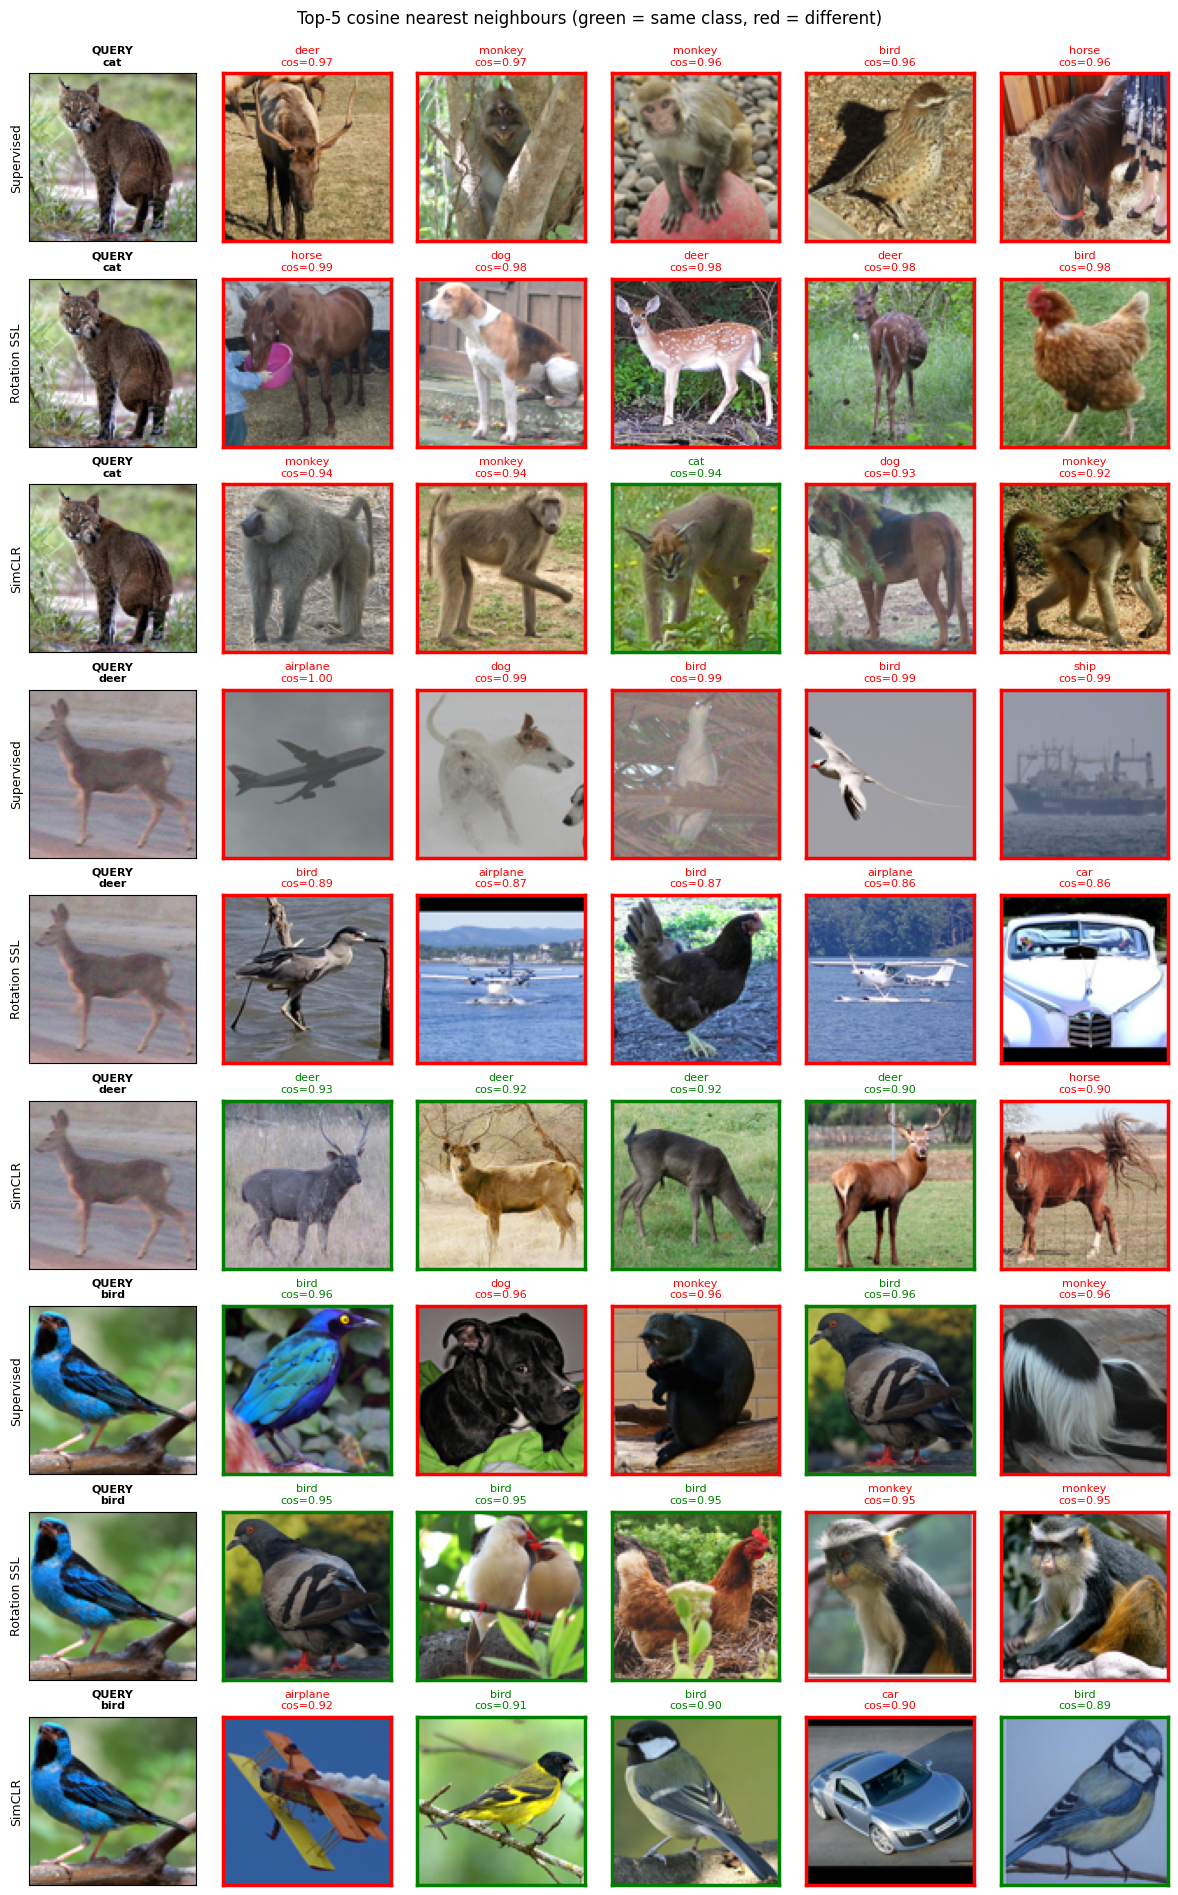

[D] Supervised: kNN precision@5 over all test images = 36.36%
[D] Rotation SSL: kNN precision@5 over all test images = 40.96%
[D] SimCLR: kNN precision@5 over all test images = 47.46%


In [8]:
encoders = {"Supervised": enc_A, "Rotation SSL": enc_B, "SimCLR": enc_C}
EMB = {k: F.normalize(extract(e, Xte), dim=1) for k, e in encoders.items()}      # L2-normalised -> dot product = cosine sim

# same 3 query images (distinct classes, chosen with SEED) for ALL three encoders
rq = np.random.RandomState(SEED); yte_np = yte.cpu().numpy()
q_classes = rq.choice(10, 3, replace=False)
queries = [int(rq.choice(np.where(yte_np == c)[0])) for c in q_classes]
log("query test indices:", queries, "| classes:", [CLASSES[yte_np[q]] for q in queries])

def topk(emb, q, k=5):
    s = emb @ emb[q]; s[q] = -2                      # exclude the query itself
    v, i = s.topk(k); return i.cpu().numpy(), v.cpu().numpy()

def show(i): return Xte[i].permute(1, 2, 0).cpu().numpy()

fig, axes = plt.subplots(9, 6, figsize=(12, 19))
for qi, q in enumerate(queries):
    for ei, (name, emb) in enumerate(EMB.items()):
        r = qi * 3 + ei; idx, sims = topk(emb, q)
        axes[r, 0].imshow(show(q)); axes[r, 0].set_title(f"QUERY\n{CLASSES[yte_np[q]]}", fontsize=8, fontweight="bold")
        axes[r, 0].set_ylabel(name, fontsize=9, rotation=90)
        for c, (j, sv) in enumerate(zip(idx, sims)):
            ok = yte_np[j] == yte_np[q]; ax = axes[r, c+1]; ax.imshow(show(j))
            ax.set_title(f"{CLASSES[yte_np[j]]}\ncos={sv:.2f}", fontsize=8, color="green" if ok else "red")
            for sp in ax.spines.values(): sp.set_edgecolor("green" if ok else "red"); sp.set_linewidth(2.5)
for ax in axes.ravel(): ax.set_xticks([]); ax.set_yticks([])
plt.suptitle("Top-5 cosine nearest neighbours (green = same class, red = different)", y=0.995); plt.tight_layout()
plt.savefig("nn_visualization.png", dpi=130); plt.show()

# quantitative companion: precision@5 over the whole test set
P5 = {}
for name, emb in EMB.items():
    s = emb @ emb.T; s.fill_diagonal_(-2); nn_idx = s.topk(5, dim=1).indices
    P5[name] = (yte[nn_idx] == yte[:, None]).float().mean().item()
    log(f"[D] {name}: kNN precision@5 over all test images = {P5[name]*100:.2f}%")
RESULTS["D"] = dict(queries=queries, precision_at_5=P5)

## Results summary & deliverable files

In [9]:
rows = [("A  Supervised, 10% labels (end-to-end)", RESULTS["A"]["acc"]),
        ("B  Rotation SSL + frozen linear probe",   RESULTS["B"]["acc"]),
        ("C  SimCLR (τ=0.2) + frozen linear probe", RESULTS["C"]["acc"])]
for n, a in rows: log(f"{n:45s} test acc = {a*100:.2f}%")

md_txt = f'''# METRICS — STL-10 SSL (SID4={SID4}, SEED={SEED})

Backbone: ResNet-18, no pretrained weights. Labeled subset: {len(idx10)} images (10%, stratified). Test set: {len(yte)} images.

| Part | Method | Pretrain epochs | Linear/Train epochs | Test accuracy |
|---|---|---|---|---|
| A | Supervised (10% labels) | – | {RESULTS["A"]["epochs"]} | {RESULTS["A"]["acc"]*100:.2f}% |
| B | Rotation SSL + linear probe | {RESULTS["B"]["pretrain_epochs"]} | {RESULTS["B"]["linear_epochs"]} | {RESULTS["B"]["acc"]*100:.2f}% |
| C | SimCLR (τ={TAU}) + linear probe | {RESULTS["C"]["pretrain_epochs"]} | {RESULTS["C"]["linear_epochs"]} | {RESULTS["C"]["acc"]*100:.2f}% |

Rotation pretext accuracy (last epoch): {RESULTS["B"]["pretext_acc"]*100:.1f}%  |  SimCLR unlabeled images: {RESULTS["C"]["n_unlabeled"]}

## Part D — kNN precision@5 (cosine, whole test set)
''' + "\n".join(f"- {k}: {v*100:.2f}%" for k, v in P5.items()) + f"\n\nQuery test indices: {queries}\n"
open("METRICS.md", "w").write(md_txt); print(md_txt)

A  Supervised, 10% labels (end-to-end)        test acc = 38.12%
B  Rotation SSL + frozen linear probe         test acc = 49.31%
C  SimCLR (τ=0.2) + frozen linear probe       test acc = 53.80%
# METRICS — STL-10 SSL (SID4=6638, SEED=6638)

Backbone: ResNet-18, no pretrained weights. Labeled subset: 500 images (10%, stratified). Test set: 8000 images.

| Part | Method | Pretrain epochs | Linear/Train epochs | Test accuracy |
|---|---|---|---|---|
| A | Supervised (10% labels) | – | 15 | 38.12% |
| B | Rotation SSL + linear probe | 15 | 20 | 49.31% |
| C | SimCLR (τ=0.2) + linear probe | 20 | 20 | 53.80% |

Rotation pretext accuracy (last epoch): 83.2%  |  SimCLR unlabeled images: 20000

## Part D — kNN precision@5 (cosine, whole test set)
- Supervised: 36.36%
- Rotation SSL: 40.96%
- SimCLR: 47.46%

Query test indices: [3808, 2548, 3442]



## Analysis

| Model | Test acc. | kNN precision@5 (8,000 test images) |
|---|---|---|
| A — Supervised, 500 labels | 38.12% | 36.36% |
| B — Rotation SSL + frozen linear probe | 49.31% | 40.96% |
| C — SimCLR (τ = 0.2) + frozen linear probe | **53.80%** | **47.46%** |

**1. Which model performed best, and why?**
SimCLR (53.8%), then rotation (49.3%), then supervised (38.1%). SimCLR's objective directly asks for what a classifier needs: two heavily augmented views (random crop, flip, colour jitter, grayscale) of the same image must map close together while all other images are pushed away. Surviving those augmentations forces the encoder to ignore colour, position and scale and keep object-level content, so the features are semantic and a linear layer on 500 labels can separate them. SimCLR also used only 20k unlabeled images, so it beat rotation despite seeing 5× less unlabeled data.

**2. Why did the other models perform the way they did?**
- *Supervised (38.1%):* 500 images with batch 64 is only ~8 steps per epoch, so 15 epochs is ~120 gradient updates from random init. The loss was still falling (2.33 → 0.88), so this is undertrained and data-starved. It never sees the 100k unlabeled images, so it has little signal to learn general features from.
- *Rotation (49.3%):* the pretext task reached 83% accuracy, but it can be solved with cues that are not class-specific, such as sky/ground layout, horizon lines, background texture or black letterbox borders. The encoder learns scene geometry and background more than object identity, and the last-layer features are specialised to the pretext task, which hurts transfer. It still clearly beat supervised, so the unlabeled data helped.
- *SimCLR (53.8%):* still not converged. NT-Xent was still falling (2.70) and contrastive top-1 was still rising (80%) at epoch 20, and 20k images with batch 256 (510 negatives) is small by SimCLR standards.

**3. What could improve each model?**
- *Supervised:* more update steps (smaller batch such as 16–32, or more epochs), stronger augmentation, label smoothing/mixup, a learning-rate schedule, and more care with weight decay.
- *Rotation:* longer pretraining, add crop/colour augmentation to the rotation task so it cannot use trivial cues, probe intermediate layers (layer3) instead of only the final pooled features, and train on all unlabeled data with a stronger probe.
- *SimCLR:* train longer, use all 100k images, a larger batch (or a memory queue) for more negatives, a cosine LR schedule with warmup (or LARS), a stronger/better-tuned augmentation set, and try τ values around 0.1–0.5. A small MLP probe or light fine-tuning on the 500 labels would also raise accuracy.

**4. What did the nearest-neighbour visualisations show?**
Across the 3 queries (15 neighbours per model), same-class neighbours were: Supervised 2/15, Rotation 3/15, SimCLR 8/15, matching the kNN precision@5 ordering above.
- *Supervised* retrieves by low-level appearance: the grey deer query returns an airplane, a dog, two birds and a ship (all pale grey, low-contrast backgrounds), and the cat returns brown animals in earthy scenes. Its cosine similarities are all ≈0.96–1.00, meaning the embeddings sit in a narrow cone and are barely discriminative.
- *Rotation* retrieves by scene and layout rather than object: the cat query returns mostly animals in green, grassy scenes (deer, deer, chicken), and the deer returns birds/planes on water plus a car and plane with black letterbox bars, which suggests border/scene cues are being used.
- *SimCLR* is the most semantic: 4 of 5 neighbours of the deer are deer, with colour, background and pose varying. Its failures are still plausible look-alikes (monkeys/dog for the cat, a horse for the deer), though an airplane and a car also appear for the bird query.

*Caveat:* a single run with one seed. With only 500 labels, seed-to-seed variation could be a few points, so the ordering is clear but the exact gaps are not tight.